In [3]:
# Импорты и настройки
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from src.data import load_raw_data, aggregate_sales_by_category
from src.features import build_features
from src.models import (
    naive_last_predict, moving_average_predict,
    RidgeForecaster, evaluate
)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [6]:
# Загрузка конфигов и агрегация
with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

raw = load_raw_data("../" + cfg["data"]["raw_path"])
cat_series = aggregate_sales_by_category(raw)

print("Категории и длина рядов:")
for cat, s in cat_series.items():
    print(f"{cat}: {len(s)} дней с {s['date'].min().date()} по {s['date'].max().date()}")

Категории и длина рядов:
Groceries: 731 дней с 2022-01-01 по 2024-01-01
Furniture: 731 дней с 2022-01-01 по 2024-01-01
Electronics: 731 дней с 2022-01-01 по 2024-01-01
Clothing: 731 дней с 2022-01-01 по 2024-01-01
Toys: 731 дней с 2022-01-01 по 2024-01-01


In [25]:
# EDA
print("Первые строки датасета:")
print(raw.head())

Первые строки датасета:
        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001    Groceries  North              231   
1 2022-01-01     S004      P0013    Furniture   East              191   
2 2022-01-01     S004      P0012  Electronics  North              349   
3 2022-01-01     S004      P0011  Electronics   West              205   
4 2022-01-01     S004      P0010    Groceries   East              447   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1          56             65            54.47  61.81         0   
2           9            165             0.95  14.25         5   
3          46             27            46.65  54.84         0   
4         104             96           115.03  33.48        15   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Aut

In [14]:
print("Проверка на пропуски")
print(raw.isna())

Проверка на пропуски
        Date  Store ID  Product ID  Category  Region  Inventory Level  \
0      False     False       False     False   False            False   
1      False     False       False     False   False            False   
2      False     False       False     False   False            False   
3      False     False       False     False   False            False   
4      False     False       False     False   False            False   
...      ...       ...         ...       ...     ...              ...   
73095  False     False       False     False   False            False   
73096  False     False       False     False   False            False   
73097  False     False       False     False   False            False   
73098  False     False       False     False   False            False   
73099  False     False       False     False   False            False   

       Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0           False          False

In [26]:
print("Информация о столбцах и типах: ")
print(raw.info())

Информация о столбцах и типах: 
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100

In [13]:
print("Базовые описательные статистики: ")
print(raw.describe())

Базовые описательные статистики: 
                      Date  Inventory Level    Units Sold  Units Ordered  \
count                73100     73100.000000  73100.000000   73100.000000   
mean   2023-01-01 00:00:00       274.469877    136.464870     110.004473   
min    2022-01-01 00:00:00        50.000000      0.000000      20.000000   
25%    2022-07-02 00:00:00       162.000000     49.000000      65.000000   
50%    2023-01-01 00:00:00       273.000000    107.000000     110.000000   
75%    2023-07-03 00:00:00       387.000000    203.000000     155.000000   
max    2024-01-01 00:00:00       500.000000    499.000000     200.000000   
std                    NaN       129.949514    108.919406      52.277448   

       Demand Forecast         Price      Discount  Holiday/Promotion  \
count     73100.000000  73100.000000  73100.000000       73100.000000   
mean        141.494720     55.135108     10.009508           0.497305   
min          -9.990000     10.000000      0.000000           0

In [27]:
print("Базовые описательные статистики отдельно для каждой категории: ")
for cat, df in cat_series.items():
    print(f"=== {cat} ===")
    display(df['sales'].describe())
    print("\n")

Базовые описательные статистики отдельно для каждой категории: 
=== Groceries ===


count     731.000000
mean     2736.637483
std       726.571215
min       863.000000
25%      2239.500000
50%      2665.000000
75%      3213.000000
max      5465.000000
Name: sales, dtype: float64



=== Furniture ===


count     731.000000
mean     2770.201094
std       758.666813
min       929.000000
25%      2228.500000
50%      2729.000000
75%      3259.500000
max      5551.000000
Name: sales, dtype: float64



=== Electronics ===


count     731.000000
mean     2681.849521
std       725.128931
min       721.000000
25%      2188.500000
50%      2616.000000
75%      3120.000000
max      5053.000000
Name: sales, dtype: float64



=== Clothing ===


count     731.000000
mean     2734.837209
std       729.970082
min       843.000000
25%      2202.500000
50%      2723.000000
75%      3196.500000
max      5227.000000
Name: sales, dtype: float64



=== Toys ===


count     731.000000
mean     2722.961696
std       709.291693
min       713.000000
25%      2214.000000
50%      2680.000000
75%      3172.000000
max      5340.000000
Name: sales, dtype: float64

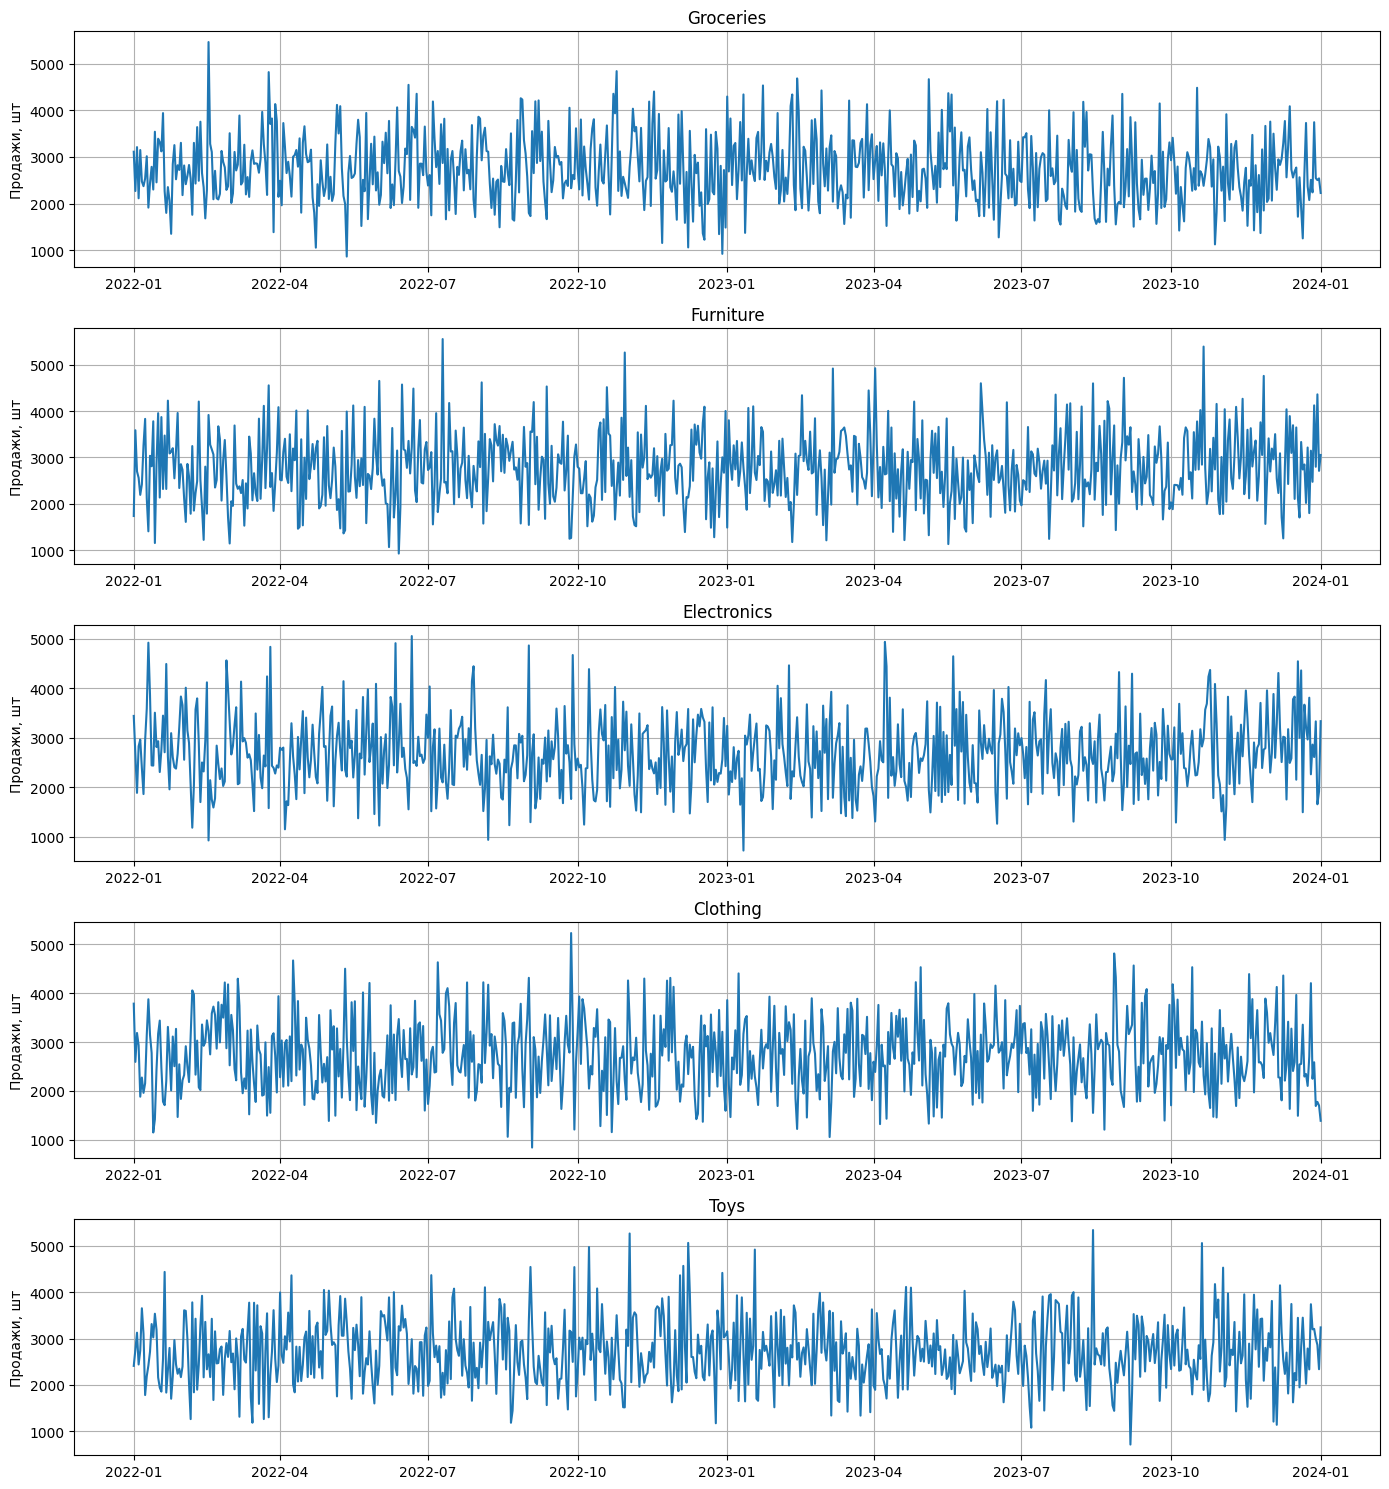

In [15]:
# Визуализация рядов по категориям
n_cats = len(cat_series)
fig, axes = plt.subplots(n_cats, 1, figsize=(14, 3 * n_cats))
for ax, (cat, s) in zip(axes, cat_series.items()):
    ax.plot(s['date'], s['sales'], lw=1.5)
    ax.set_title(cat)
    ax.set_ylabel('Продажи, шт')
plt.tight_layout()
plt.show()

In [16]:
# Подготовка данных и baseline для одной категории (Groceries)
cat = 'Groceries'
series = cat_series[cat]

# строим признаки
feat_df = build_features(series, 'sales',
                         lags=cfg['features']['lags'],
                         rolling_windows=cfg['features']['rolling_windows'])

# временное разбиение
def temporal_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    tr_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return df.iloc[:tr_end], df.iloc[tr_end:val_end], df.iloc[val_end:]

train_df, val_df, test_df = temporal_split(feat_df)
feature_cols = [c for c in feat_df.columns if c not in ('date', 'sales')]

y_train = train_df['sales'].values
y_val = val_df['sales'].values

In [ ]:
# Baseline-модели
# B1 – наивный (последнее значение)
naive_pred = naive_last_predict(y_train, len(y_val))
print("B1 Naive:", evaluate(y_val, naive_pred, "naive_last"))

# B2 – скользящее среднее (окно 7)
ma_pred = moving_average_predict(y_train, window=7, horizon=len(y_val))
print("B2 MovingAvg:", evaluate(y_val, ma_pred, "moving_avg"))

# B3 – Ridge на лаговых и календарных признаках
ridge = RidgeForecaster(alpha=1.0)
ridge.fit(train_df[feature_cols], y_train)
ridge_pred = ridge.predict(val_df[feature_cols])
print("B3 Ridge:", evaluate(y_val, ridge_pred, "ridge"))

B1 Naive: {'model': 'naive_last', 'MAE': 963.5555555555555, 'RMSE': 1113.08226543667, 'MAPE_%': 46.51164254225179}
B2 MovingAvg: {'model': 'moving_avg', 'MAE': 717.222222222222, 'RMSE': 833.4964346056784, 'MAPE_%': 33.298655023212916}
B3 Ridge: {'model': 'ridge', 'MAE': 682.2577891304277, 'RMSE': 795.602219376158, 'MAPE_%': 31.396391490385906}


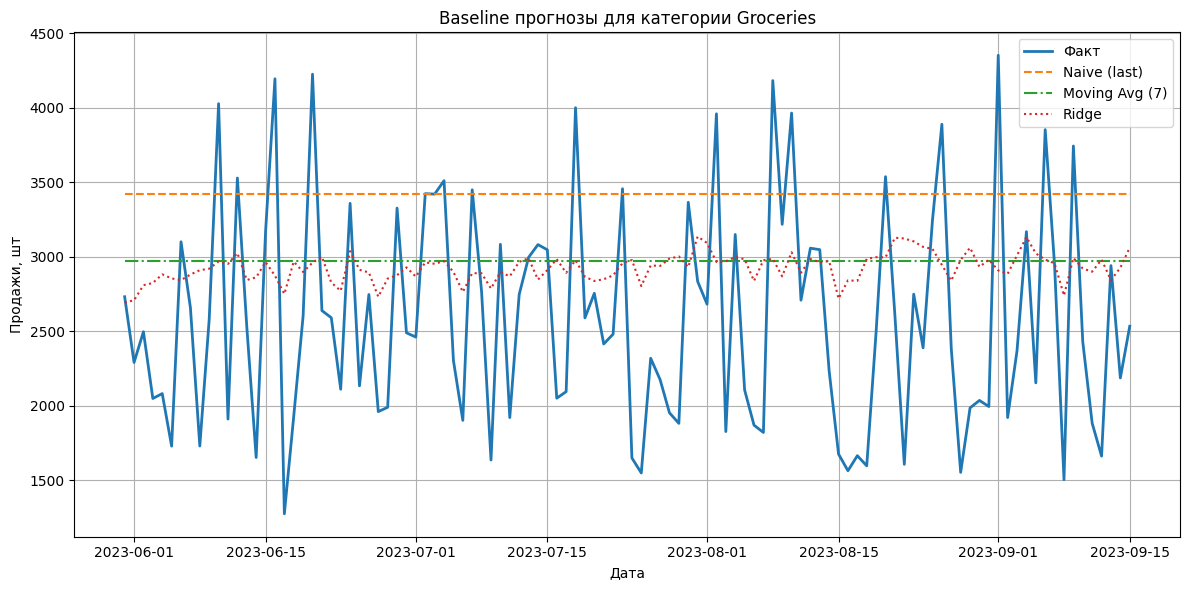

In [18]:
# Визуализация прогнозов baseline
plt.figure(figsize=(12, 6))
plt.plot(val_df['date'], y_val, label='Факт', lw=2)
plt.plot(val_df['date'], naive_pred, label='Naive (last)', linestyle='--')
plt.plot(val_df['date'], ma_pred, label='Moving Avg (7)', linestyle='-.')
plt.plot(val_df['date'], ridge_pred, label='Ridge', linestyle=':')
plt.legend()
plt.title(f'Baseline прогнозы для категории {cat}')
plt.xlabel('Дата')
plt.ylabel('Продажи, шт')
plt.tight_layout()
plt.show()

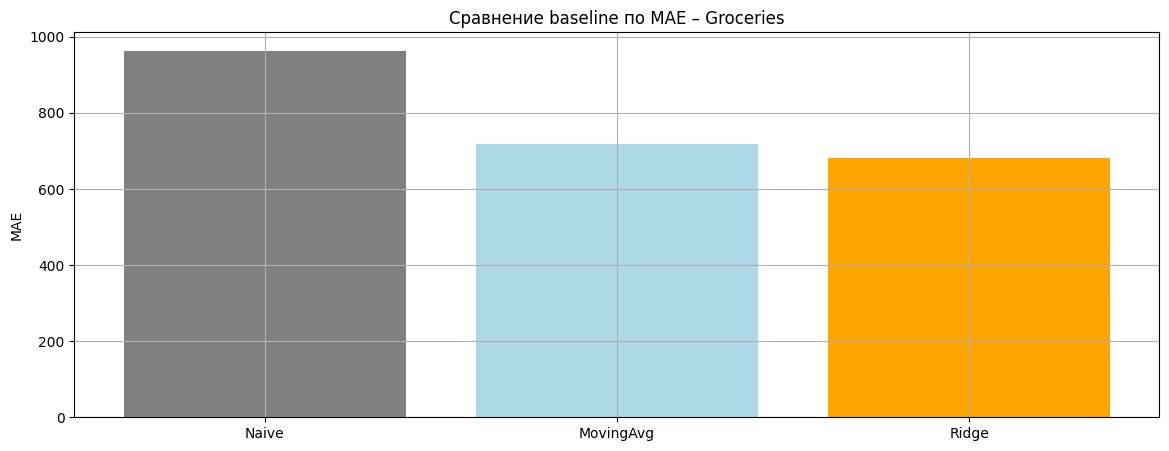

In [19]:
# Сравнение MAE по baseline (столбчатая диаграмма)
metrics = {
    "Naive": evaluate(y_val, naive_pred)["MAE"],
    "MovingAvg": evaluate(y_val, ma_pred)["MAE"],
    "Ridge": evaluate(y_val, ridge_pred)["MAE"]
}
plt.bar(metrics.keys(), metrics.values(), color=['gray', 'lightblue', 'orange'])
plt.ylabel('MAE')
plt.title(f'Сравнение baseline по MAE – {cat}')
plt.show()